# Scalar Carleman trajectories

## Imports and parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import lambertw
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import expm_multiply

x0 = 0.2
orders = [1, 3, 5, 10, 20]
time_points = 2001
cases = [
    (1, 1.0, "Positive system"),
    (-1, 10.0, "Negative system"),
]

## Model and Simulation Functions

The scalar examples are

$$
\dot{x}^{\pm}(t)=\pm\frac{x^{\pm}(t)}{1+(x^{\pm}(t))^2},
\qquad x^{\pm}(0)=x_0.
$$

Their implicit solution is

$$
\ln |x^{\pm}(t)|+\frac{(x^{\pm}(t))^2}{2}\mp t
=
\ln x_0+\frac{x_0^2}{2},
$$

and the explicit solution is

$$
x^{\pm}(t)=
\sqrt{W\!\left(x_0^2e^{x_0^2\pm2t}\right)},
$$

where $W$ is the Lambert $W$ function.

For truncation order $N$, the finite Carleman matrix is

$$
A_{k\ell}^{\pm}=
\begin{cases}
\pm k(-1)^{(\ell-k)/2}, & \ell\geq k\text{ and }\ell-k\text{ is even},\\
0, & \text{otherwise},
\end{cases}
$$

with

$$
y_N(0)=\begin{bmatrix}x_0&x_0^2&\cdots&x_0^N\end{bmatrix}^{T}.
$$

In [2]:
def exact_solution(times, initial, sign):
    argument = initial**2 * np.exp(initial**2 + 2.0 * sign * times)
    return np.sqrt(lambertw(argument).real)


def carleman_matrix(order, sign):
    rows = []
    columns = []
    values = []

    for k in range(1, order + 1):
        for ell in range(k, order + 1, 2):
            rows.append(k - 1)
            columns.append(ell - 1)
            values.append(sign * k * (-1) ** ((ell - k) // 2))

    return csr_matrix(
        (values, (rows, columns)),
        shape=(order, order),
        dtype=float,
    )


def carleman_solution(times, initial, order, sign):
    matrix = carleman_matrix(order, sign)
    lifted_initial = initial ** np.arange(1, order + 1, dtype=float)

    lifted = expm_multiply(
        matrix,
        lifted_initial,
        start=float(times[0]),
        stop=float(times[-1]),
        num=times.size,
        endpoint=True,
        traceA=float(matrix.diagonal().sum()),
    )
    return lifted[:, 0]


def numerical_solution(times, initial, sign):
    return solve_ivp(
        lambda _, state: sign * state / (1.0 + state**2),
        (times[0], times[-1]),
        [initial],
        t_eval=times,
        rtol=1e-12,
        atol=1e-14,
    ).y[0]

## Simulation

In [3]:
simulations = {}

for sign, final_time, title in cases:
    times = np.linspace(0.0, final_time, time_points)
    exact = exact_solution(times, x0, sign)
    numerical = numerical_solution(times, x0, sign)
    approximations = {
        order: carleman_solution(times, x0, order, sign)
        for order in orders
    }
    errors = {
        order: np.abs(approximations[order] - exact)
        for order in orders
    }

    simulations[title] = {
        "sign": sign,
        "times": times,
        "exact": exact,
        "numerical": numerical,
        "approximations": approximations,
        "errors": errors,
    }

## Results

Positive system
  Exact solution check: 3.391e-13
  First-order check:    0.000e+00
  N= 1: maximum error = 5.212893e-02
  N= 3: maximum error = 1.734009e-02
  N= 5: maximum error = 7.630745e-03
  N=10: maximum error = 2.141391e-03
  N=20: maximum error = 1.991289e-04

Negative system
  Exact solution check: 4.793e-14
  First-order check:    0.000e+00
  N= 1: maximum error = 1.529393e-03
  N= 3: maximum error = 2.503490e-05
  N= 5: maximum error = 5.405060e-07
  N=10: maximum error = 3.689625e-10
  N=20: maximum error = 1.665335e-16



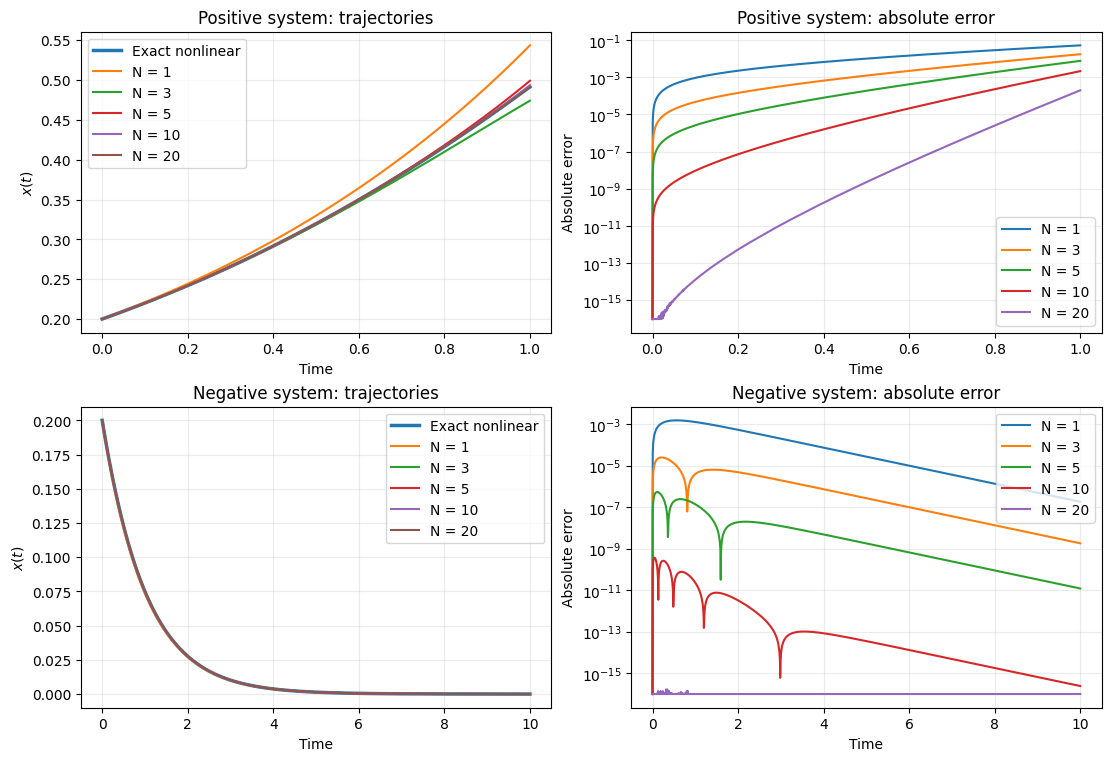

: 

In [ ]:
figure, axes = plt.subplots(2, 2, figsize=(11.0, 7.5), constrained_layout=True)

for row, (title, data) in enumerate(simulations.items()):
    times = data["times"]
    exact = data["exact"]

    axes[row, 0].plot(times, exact, linewidth=2.5, label="Exact nonlinear")

    for order in orders:
        approximation = data["approximations"][order]
        error = data["errors"][order]
        axes[row, 0].plot(times, approximation, label=f"N = {order}")
        axes[row, 1].semilogy(times, np.maximum(error, 1e-16), label=f"N = {order}")

    axes[row, 0].set_title(f"{title}: trajectories")
    axes[row, 1].set_title(f"{title}: absolute error")
    axes[row, 0].set_ylabel(r"$x(t)$")
    axes[row, 1].set_ylabel("Absolute error")

    for axis in axes[row]:
        axis.set_xlabel("Time")
        axis.grid(True, alpha=0.25)
        axis.legend()


for title, data in simulations.items():
    sign = data["sign"]
    times = data["times"]
    first_order_reference = x0 * np.exp(sign * times)

    print(title)
    print(f"  Exact solution check: {np.max(np.abs(data['exact'] - data['numerical'])):.3e}")
    print(
        "  First-order check:    "
        f"{np.max(np.abs(data['approximations'][1] - first_order_reference)):.3e}"
    )
    
    for order in orders:
        print(f"  N={order:2d}: maximum error = {data['errors'][order].max():.6e}")
    
    print()